# Cargar los csv

In [34]:
import pandas as pd
from os import path
import matplotlib.pyplot as plt



class Dataset:
    def __init__(self, data=None, archivo="denoise_log.csv"):
        self.metadata = ["step", "call", "batch", "iteration", "time", "num_steps"]
        if data is not None:
            self.data = data
        else:
            self.data = self._load_dataset(archivo)
            self.data = self._filter_noise()
            self.data = self._reshape_to_long()

    def _load_dataset(self, archivo):
        path_csv = path.join("output", "pi0_denoise", archivo)
        return pd.read_csv(path_csv)

    def _filter_noise(self):
        v_cols_to_keep = self._get_names_of_action_columns()
        return self.data[self.metadata + v_cols_to_keep]

    def _get_names_of_action_columns(self):
        v_cols = [c for c in self.data.columns if c.startswith("v")]
        chunk_size = 32
        keep = 7
        return [c for c in v_cols if int(c[1:]) % chunk_size < keep]

    def _reshape_to_long(self):
        v_cols = self._get_names_of_action_columns()
        n_chunks = len(v_cols) // 7

        coord_names = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]

        chunks = []
        for chunk_idx in range(n_chunks):
            chunk_v_cols = v_cols[chunk_idx * 7: (chunk_idx + 1) * 7]
            chunk_df = self.data[self.metadata + chunk_v_cols].copy()
            chunk_df = chunk_df.rename(columns={c: coord_names[j] for j, c in enumerate(chunk_v_cols)})
            chunk_df["action_in_chunk"] = chunk_idx + 1
            chunk_df["chunk"] = self.data.index  # fila original
            chunks.append(chunk_df)

        return pd.concat(chunks, ignore_index=True)
    
    def filter_by_step(self, step):
        return Dataset(data=self.data[self.data["step"] == step])

    def filter_by_action_in_chunk(self, number_of_action_in_chunk):
        return Dataset(data=self.data[self.data["action_in_chunk"] == number_of_action_in_chunk])

    def filter_only_last_vector(self):
        return Dataset(data=self.data[self.data["iteration"] == 10])

    def sum_by_chunk(self):
        grouped = self.data.groupby("chunk")[["x", "y", "z", "roll", "pitch", "yaw", "gripper"]].sum().reset_index()
        return Dataset(data=grouped)

    def cumsum_by_chunk(self):
        grouped = self.sum_by_chunk().data.sort_values("chunk")
        grouped[["x", "y", "z", "roll", "pitch", "yaw", "gripper"]] = grouped[["x", "y", "z", "roll", "pitch", "yaw", "gripper"]].cumsum()
        return Dataset(data=grouped)

Dataset().filter_by_step(2).filter_by_action_in_chunk(2).data
# Creo que no me estás entendiendo. Cada chunk es una seguidilla de acciones. Las acciones pertenecientes al mismo chunk


,step,call,batch,iteration,time,num_steps,x,y,z,roll,pitch,yaw,gripper,action_in_chunk,chunk
10890,2,201,0,0,1.000000e+00,10,0.115418,-0.283125,-0.066209,-1.369944,0.429698,-0.512476,-0.693390,2,2200
10891,2,201,0,1,9.000000e-01,10,0.103106,-0.331429,-0.045552,-1.230507,0.402615,-0.457358,-0.722863,2,2201
10892,2,201,0,2,8.000000e-01,10,0.090141,-0.385401,-0.020604,-1.094255,0.377894,-0.408620,-0.751155,2,2202
10893,2,201,0,3,6.999999e-01,10,0.079331,-0.441157,0.007303,-0.956364,0.348669,-0.359147,-0.782099,2,2203
10894,2,201,0,4,5.999999e-01,10,0.068850,-0.497149,0.035033,-0.821653,0.321218,-0.310535,-0.806071,2,2204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15109,2,584,0,6,3.999999e-01,10,-0.109046,0.425758,0.174375,0.103678,0.305216,-0.127580,-1.441133,2,6419
15110,2,584,0,7,2.999999e-01,10,-0.086418,0.231323,0.189120,0.070156,0.206477,-0.067309,-1.326572,2,6420
15111,2,584,0,8,1.999999e-01,10,-0.066978,0.051767,0.198883,0.038303,0.100449,-0.008197,-1.205262,2,6421
15112,2,584,0,9,9.999993e-02,10,-0.047900,-0.107597,0.202311,0.015468,-0.005427,0.044348,-1.075112,2,6422


In [35]:
archivo = "denoise_big_noise_cm.csv"
step = 2

# Estudio de desviación estándar
En cada paso, cual es la desviación estándar de cada coordenada.

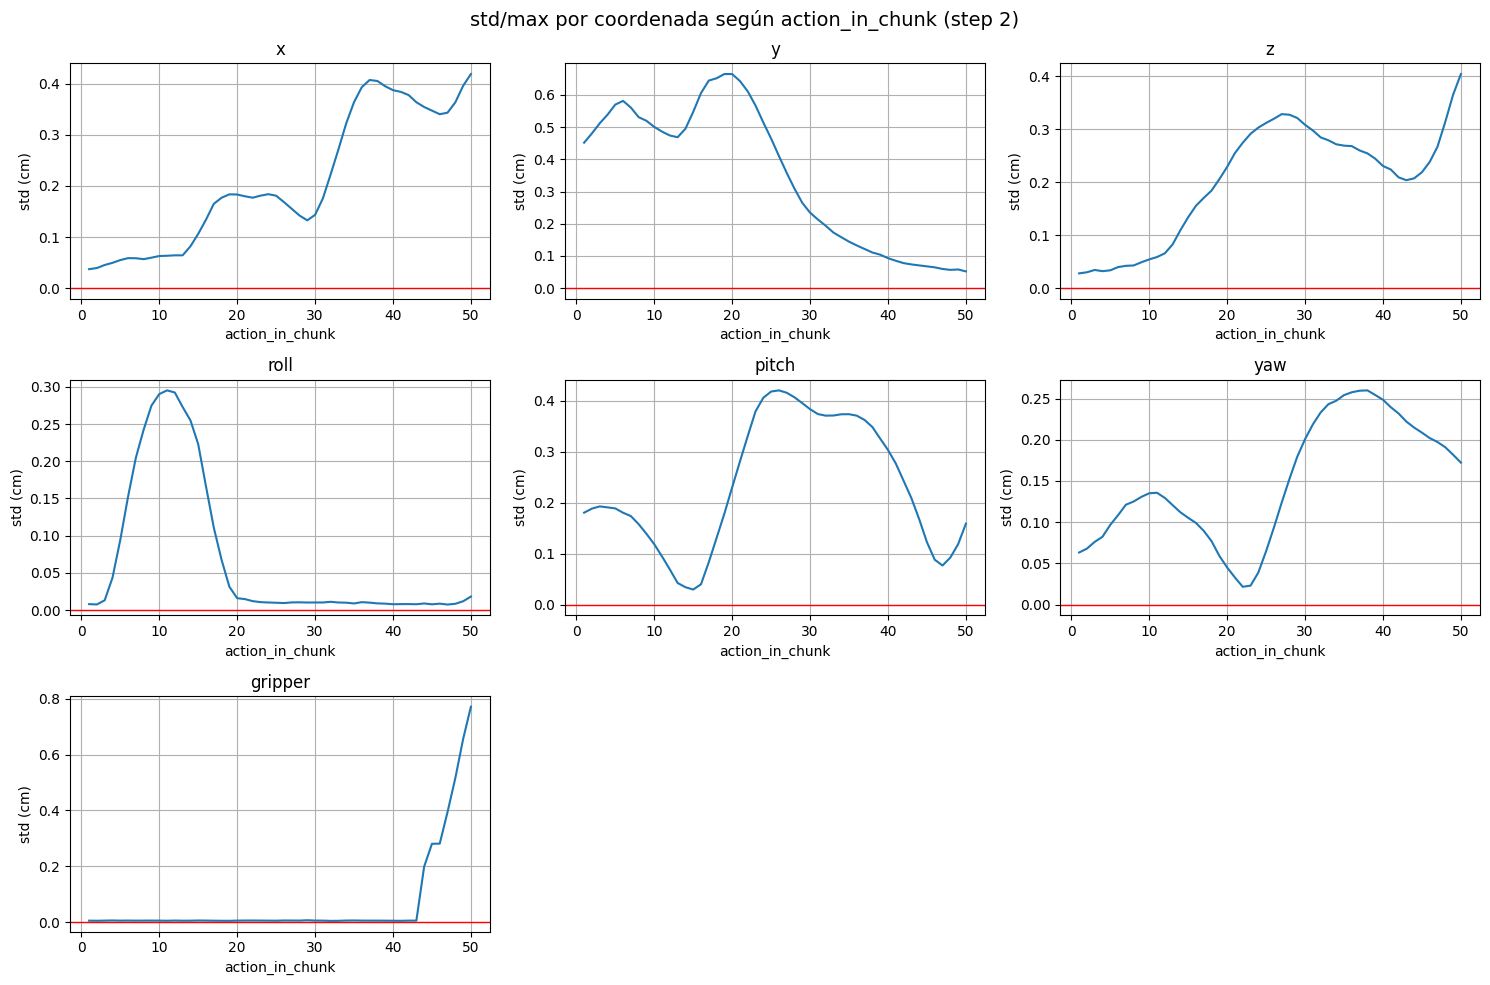

In [36]:
from pandas import DataFrame


COORD_NAMES = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]


def compute_std(df) -> DataFrame:
    results = {}
    for action in sorted(df["action_in_chunk"].unique()):
        chunk = df[df["action_in_chunk"] == action][COORD_NAMES]
        results[action] = chunk.std()# / chunk.max()
    return pd.DataFrame(results).T.rename_axis("action_in_chunk")


def plot_coord(ax, plot_df, coord) -> None:
    ax.plot(plot_df.index, plot_df[coord])
    ax.axhline(0, color="red", linewidth=1)
    ax.set_title(coord)
    ax.set_xlabel("action_in_chunk")
    ax.set_ylabel("std (cm)")
    ax.grid(True)


def plot_std_over_max_grid(step=0, archivo="denoise_log.csv") -> None:
    df = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().data
    plot_df = compute_std(df)

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, coord in enumerate(COORD_NAMES):
        plot_coord(axes[i], plot_df, coord)

    for j in range(len(COORD_NAMES), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"std/max por coordenada según action_in_chunk (step {step})", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_std_over_max_grid(step=step, archivo=archivo)

# Estudio cambio acumulado


1) Sumar cada coordenada de un chunk. Luego hacer un histograma de donde queda cada valor.

2) Hacer un gráfico de x y z donde queda cada chunk. 



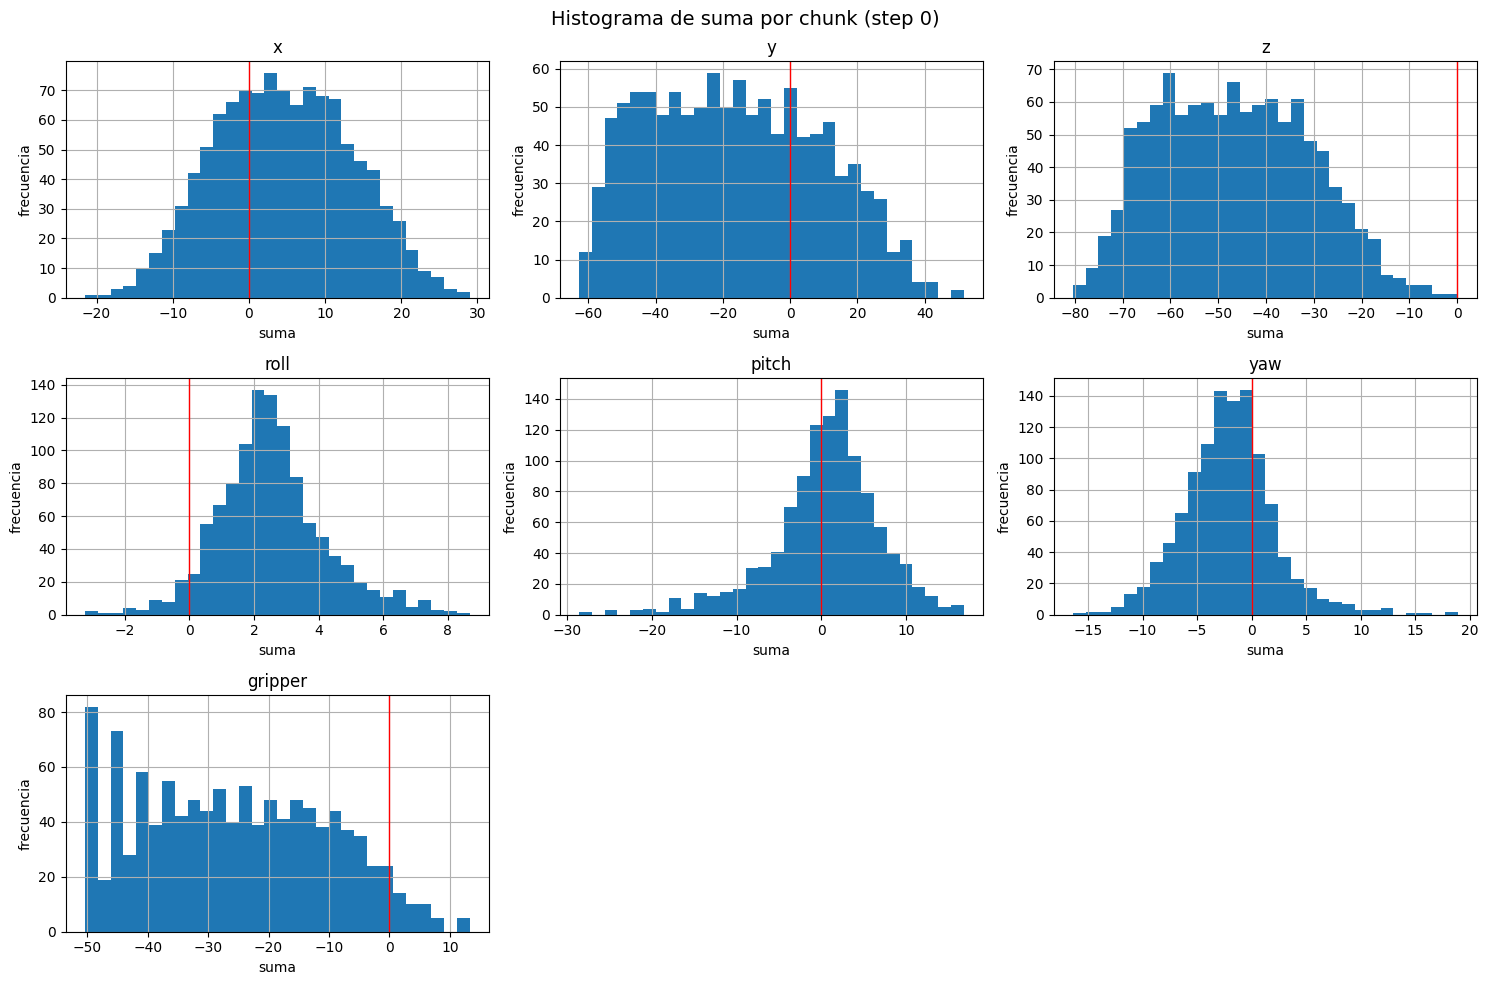

In [37]:
COORD_NAMES = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]

# --- Histograma ---
summed = Dataset(archivo=archivo).filter_by_step(step).sum_by_chunk().data

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, coord in enumerate(COORD_NAMES):
    axes[i].hist(summed[coord], bins=30)
    axes[i].axvline(0, color="red", linewidth=1)
    axes[i].set_title(coord)
    axes[i].set_xlabel("suma")
    axes[i].set_ylabel("frecuencia")
    axes[i].grid(True)

for j in range(len(COORD_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histograma de suma por chunk (step 0)", fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
import plotly.express as px

summed = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().sum_by_chunk().data

fig = px.scatter_3d(summed, x="x", y="y", z="z",
                    title=f"Posición final por chunk (step {step})")

fig.update_traces(marker=dict(size=3, color="blue"))
fig.show()

In [39]:
import plotly.express as px

summed = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().sum_by_chunk().data

fig = px.scatter_3d(summed, x="roll", y="pitch", z="yaw",
                    title=f"Posición final por chunk (step {step})")

fig.update_traces(marker=dict(size=3, color="blue"))
fig.show()